=== CIFAR10_ConvNetBN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt50: pool 5000, N_p 1000, targets [2540, 8129, 3725, 5705, 7663, 3875, 5169, 6335, 7488, 9831]
=== CIFAR10_ResNet20BN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt10: pool 5000, N_p 1000, targets [3495, 2903, 6697, 2315, 6899, 2312, 6353, 4421, 2242, 6768]
=== CIFAR10_VGG13BN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt3: pool 5000, N_p 1000, targets [3728, 5640, 6922, 7855, 2127, 7586, 7360, 2171, 4462, 2597]
wrote /Users/mohammad/Downloads/PoisonBase/figures/pdf/scattertopk_overlap_linear.pdf
wrote /Users/mohammad/Downloads/PoisonBase/figures/pdf/scattertopk_overlap_log.pdf


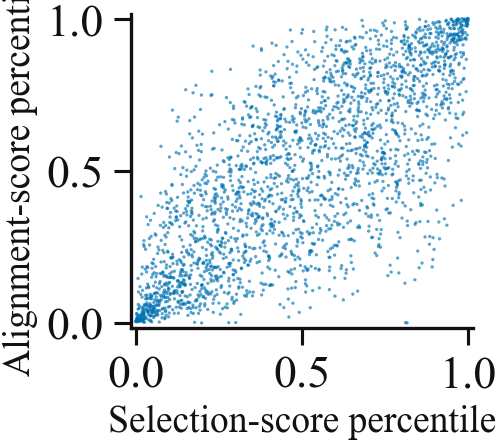

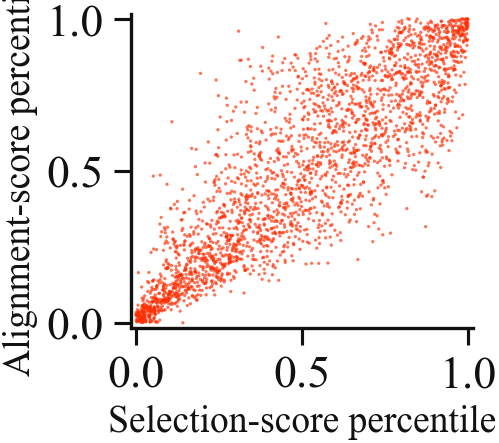

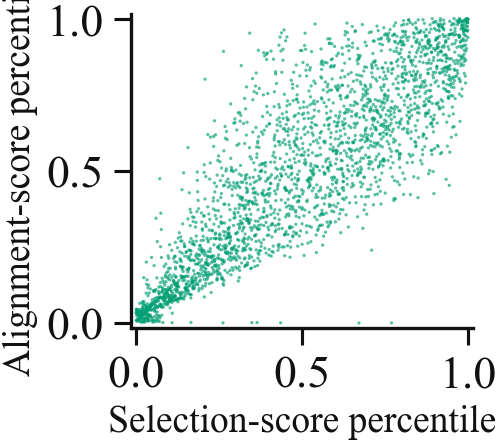

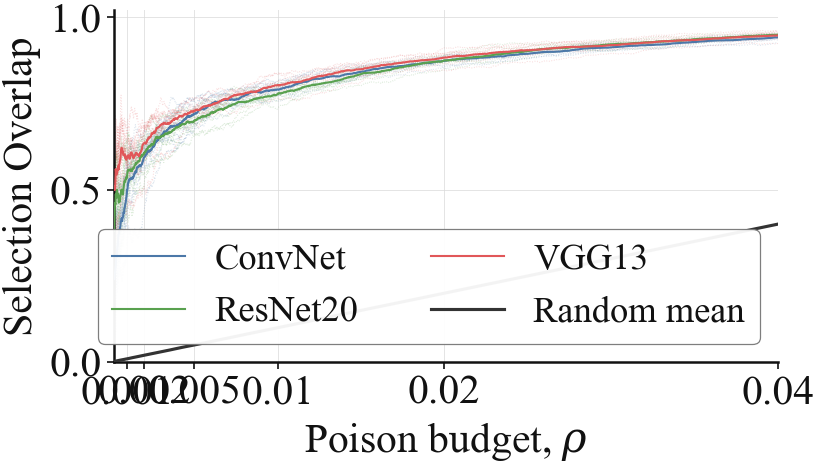

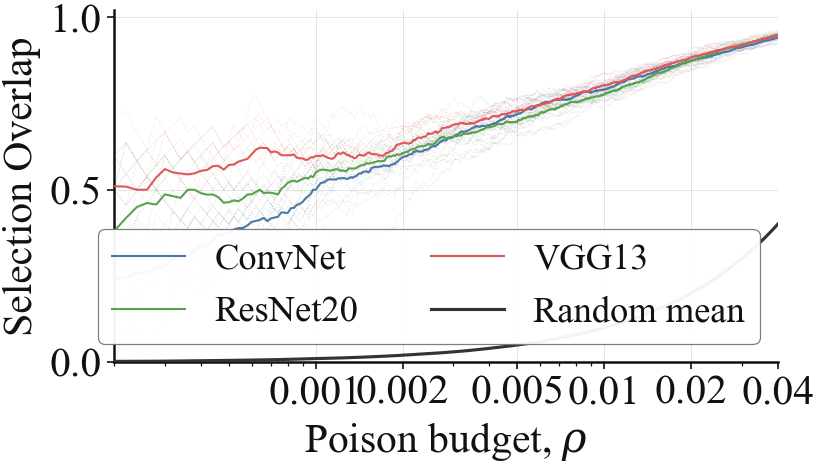

In [127]:
"""Jupyter-ready re-plotting of every experiment under scatter_result/.

Reads ONLY what final_update_scatter.py --scatter_mode saved (components.npz
and summary.json in each SCATTER_<run name>/ directory) and redraws the
figures from those arrays. Nothing is recomputed on a GPU, so every knob
below can be changed and the cell re-run in seconds.

Per experiment (one SCATTER_* directory) it can export:
  scatter_grid        raw x = rm, y = A for the saved random subset, one
                      panel per target
  rank_grid           the same subset as full-pool percentile ranks
  conditional_a       median A (with IQR band) in equal-count bins of x

Across all models selected by MODEL_FILTER it exports one combined
topk_overlap_linear figure and/or one combined topk_overlap_log figure. Each
model is represented by a thick mean curve and faint individual-target curves.

The two rankings compared by the overlap curve are defined by cheap_score()
and full_score() in USER CONTROLS, so the combination rule, the weight beta,
and the keep-lowest / keep-highest convention are all editable here.
"""

from pathlib import Path
import json
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import (
    FormatStrFormatter,
    LogFormatterMathtext,
    NullLocator,
    PercentFormatter,
)


# =============================================================================
# USER CONTROLS
# =============================================================================

RUN_SCATTER_GRID = False
RUN_CONDITIONAL = False


RUN_RANK_GRID = True
RUN_TOPK_LINEAR = True
RUN_TOPK_LOG = True
RUN_TOPK_LOG_Y = False

# Rank figures to export, keyed by (dataset, model). An empty mapping restores
# the default behavior of plotting every target selected by TARGET_FILTER.
RANK_TARGET_BY_DATASET_MODEL = {
    ("CIFAR10", "ConvNetBN"): 5705,
    ("CIFAR10", "ResNet20BN"): 6697,
    ("CIFAR10", "VGG13BN"): 2127,
}

# Where the SCATTER_* directories are, and which of them to plot. The filter
# is a tuple of substrings; an experiment is plotted when its directory name
# contains ANY of them. () plots everything.
RESULTS_ROOT = Path("scatter_result")
EXPERIMENT_FILTER = ()
# EXPERIMENT_FILTER = ("ConvNetBN_fc_ours_dog-bird",)

# Which datasets to plot, e.g. ("CIFAR100", "SVHN"). A directory name is
# SCATTER_<dataset>_<model>_..., so this matches the token right after
# SCATTER_. () plots every dataset found under RESULTS_ROOT.
DATASET_FILTER = ("CIFAR10",)
# DATASET_FILTER = ("CIFAR100",)

# Which models to plot, e.g. ("ConvNetBN", "ResNet20BN"). A directory name is
# SCATTER_<dataset>_<model>_..., so this matches the second token. () plots
# every model found under RESULTS_ROOT.
MODEL_FILTER = ("ConvNetBN", "ResNet20BN", "VGG13BN")
# MODEL_FILTER = ("ResNet20BN", "VGG13BN")

# Which targets to draw. () = every target saved in summary.json; otherwise a
# tuple of target indices, in the order they should appear.
TARGET_FILTER = ()

# Standard budgets marked on the overlap curve, as fractions of the training
# set (each becomes N_p = round(budget * N_total) on the x axis).
BUDGET_MARKS = (0.001,)
SHOW_BUDGET_MARKS = False
SHOW_BUDGET_MARK_VALUES = True
# The run's own N_p is always available as a mark as well.
SHOW_RUN_NP_MARK = True

# Empirical random baseline. Each trial draws random top-k subsets from the
# adversarial-class pool. The plot shows their mean and +/- one standard
# deviation; set SHOW_RANDOM_TRIALS=True to draw the individual trials too.
RANDOM_BASELINE_REPEATS = 100
RANDOM_BASELINE_SEED = 2026
SHOW_RANDOM_TRIALS = False
SHOW_RANDOM_STD_BAND = True

# Numeric plot-data cache. The first run writes reusable NPZ files; subsequent
# runs load them so visual-only tuning does not recompute ranks, overlaps, or
# the random baseline. Set REBUILD_PLOT_DATA_CACHE=True after changing score
# definitions, or increment PLOT_DATA_CACHE_VERSION for manual invalidation.
USE_PLOT_DATA_CACHE = True
SAVE_PLOT_DATA_CACHE = True
REBUILD_PLOT_DATA_CACHE = False
PLOT_DATA_CACHE_VERSION = 1
PLOT_DATA_ROOT = Path("figures/data/scatter")

# Overlap curve x range, as a fraction of the poison-class pool. Curves are
# evaluated over the full pool; these controls select the visible x range.
X_MAX_FRACTION = 0.04
# Linear version: left edge of the x axis. None means start at 0.
X_MIN_FRACTION = 0.0002
TOPK_X_TICKS = (0.001, 0.002, 0.005, 0.01, 0.02, 0.04)
TOPK_X_TICK_LABELS = (
    "0.001", "0.002", "0.005", "0.01", "0.02", "0.04",
)
# Log version: the smallest fraction shown (1 candidate = 1 / pool). None
# means start at the first candidate.
LOG_X_MIN_FRACTION = X_MIN_FRACTION

# Every x-axis value on the overlap plots (curves, budget marks, axis limits)
# is divided by this before plotting. Purely a display rescale: it only moves
# where things sit on the x axis, it does not change any plotted y-value or
# which k's are evaluated.
X_AXIS_DIVISOR = 10.0

# Conditional-A plot: number of equal-count bins of x.
CONDITIONAL_BINS = 20

# Scatter grid y axis: "linear" or "symlog". symlog keeps the bulk near 0
# readable while still showing the long positive tail of A.
SCATTER_Y_SCALE = "symlog"
SCATTER_SYMLOG_LINTHRESH = 0.5

# Panel grid shape for the per-target figures.
GRID_COLUMNS = 4


# -----------------------------------------------------------------------------
# The two rankings. Both are evaluated over the FULL poison-class pool of one
# target, with the arrays final_update_scatter.py's scatter_components() saved:
#   rm     = mean over surrogates of  std(d) - std(M),  d = 1 / ||f(x)-f(x_t)||^2
#   a      = mean over surrogates of  std(A)
# d_raw, m_raw, a_raw = the same three, NOT standardized. With d defined as a
# reciprocal squared distance, both rm and A are GAINS: larger is closer /
# more confident / more helpful, and the real selector keeps the LARGEST
# rm + beta * A (equivalently the smallest -rm - beta * A). This matches
# final_update_scatter.py's own topk_overlap curve exactly -- see its
# scatter_main(), which ranks by `-rm_np` (cheap) and `-rm_np - a_np` (full)
# and keeps the lowest of each; verified bit-for-bit against the
# topk_overlap_vs_full_score array it also saves into components.npz.
# KEEP_LOWEST = True  -> both functions return a COST and the k smallest win.
# KEEP_LOWEST = False -> both return a GAIN and the k largest win.
# -----------------------------------------------------------------------------

BETA = 1.0
KEEP_LOWEST = False


def cheap_score(rm, a, d_raw, m_raw, a_raw):
    """(R, M) ranking. Default: the saved gain rm = std(d) - std(M)."""
    return rm


def full_score(rm, a, d_raw, m_raw, a_raw):
    """(A, R, M) ranking. Default: rm + beta * A, the real selector."""
    return rm + BETA * a


# =============================================================================
# LABELS
# =============================================================================

SHOW_PANEL_TITLES = True

SCATTER_X_LABEL = r"$R_i + M_i$"
SCATTER_Y_LABEL = r"$A_i$"

RANK_X_LABEL = "Selection-score percentile"
RANK_Y_LABEL = "Alignment-score percentile"

CONDITIONAL_X_LABEL = "quantile of the (R, M) score  (0 = best)"
CONDITIONAL_Y_LABEL = r"median $A_i$ in bin"

TOPK_X_LABEL = r"Poison budget, $\rho$"
TOPK_Y_LABEL = r"Selection Overlap"

MODEL_LABELS = {
    "ConvNetBN": "ConvNet",
    "ResNet20BN": "ResNet20",
    "VGG13BN": "VGG13",
}
LEGEND_MODEL_LABEL = "{model}"
LEGEND_TARGET_LABEL = "Target runs"
LEGEND_RANDOM_LABEL = "Random mean"
LEGEND_RANDOM_STD_LABEL = r"Random $\pm$ 1 s.d."
LEGEND_IQR_LABEL = "inter-quartile band"

SHOW_STATS_BOX = True          # n / Pearson / Spearman box in scatter panels
STATS_BOX_FONT_SIZE = 7


# =============================================================================
# FIGURE STYLE
# =============================================================================

# All four exports use the same source size so they align cleanly when placed
# at equal widths in a one-row ICLR figure.
PANEL_SIZE = (3.375, 3.0)
SINGLE_FIG_SIZE = (5, 3.35)
FIGURE_DPI = 150

FONT_FAMILY = "serif"
SERIF_FONTS = (
    "Times New Roman",
    "Times",
    "Nimbus Roman No9 L",
    "DejaVu Serif",
)
MATH_FONTSET = "dejavuserif"

BASE_FONT_SIZE = 14
AXIS_LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 22
TITLE_FONT_SIZE = 18
PANEL_TITLE_FONT_SIZE = 16
LEGEND_FONT_SIZE = 11.5
ANNOTATION_FONT_SIZE = 11
TEXT_COLOR = "#111111"

SPINE_LINE_WIDTH = 1.6
MAJOR_TICK_LENGTH = 8.0
MAJOR_TICK_WIDTH = 1.5
TICK_LABEL_PAD = 5.0

SHOW_GRID = False
GRID_COLOR = "#D5D8DC"
GRID_LINE_WIDTH = 0.0
GRID_ALPHA = 0.0

# Marks
POINT_SIZE = 2.5
POINT_ALPHA = 0.65

MODEL_COLORS = {
    "ConvNetBN": "#0072B2",
    "ResNet20BN": "#FF2C00",
    "VGG13BN": "#009E73",
}
TOPK_MODEL_COLORS = {
    "ConvNetBN": "#4C78A8",
    "ResNet20BN": "#59A14F",
    "VGG13BN": "#E15759",
}
MEAN_LINE_STYLE = "-"
TARGET_LINE_STYLE = ":"
TARGET_LINE_WIDTH = 0.5
TARGET_LINE_ALPHA = 0.2
MEAN_LINE_WIDTH = 1
RANDOM_LINE_COLOR = "#8C8C8C"
RANDOM_LINE_WIDTH = 0.7
RANDOM_LINE_ALPHA = 0.22
RANDOM_MEAN_COLOR = "#333333"
RANDOM_MEAN_WIDTH = 1.5
RANDOM_STD_COLOR = "#A6A6A6"
RANDOM_STD_ALPHA = 0.28
IQR_FILL_COLOR = "#2a78d6"
IQR_FILL_ALPHA = 0.12

BUDGET_MARK_COLOR = "#B0B0B0"
BUDGET_MARK_WIDTH = 0.7
BUDGET_MARK_STYLE = "--"
BUDGET_MARK_TEXT_COLOR = "#555555"
BUDGET_MARK_TEXT_Y = 0.02       # axes fraction
RUN_NP_MARK_COLOR = "#E69F00"

ZERO_LINE_COLOR = "#B0B0B0"
ZERO_LINE_WIDTH = 0.8

# Overlap y axis
TOPK_Y_LIMITS = (0.0, 1.02)
TOPK_Y_TICKS = (0.0, 0.5, 1.0)
TOPK_Y_AS_PERCENT = False
TOPK_LOG_Y_LIMITS = (1e-3, 1.05)
TOPK_LOG_Y_TICKS = (1e-3, 1e-2, 1e-1, 1.0)

# TOPK-only presentation. These restore the earlier wide, lighter plot while
# leaving the three rank panels on the newer four-across paper style.
TOPK_AXIS_LABEL_FONT_SIZE = 20
TOPK_TICK_FONT_SIZE = 20
TOPK_LEGEND_FONT_SIZE = 17.5
TOPK_SPINE_LINE_WIDTH = 1.2
TOPK_MAJOR_TICK_LENGTH = 3.5
TOPK_MAJOR_TICK_WIDTH = 0.8
TOPK_TICK_LABEL_PAD = 2.5
TOPK_GRID_COLOR = "#D9D9D9"
TOPK_GRID_LINE_WIDTH = 0.45
TOPK_GRID_ALPHA = 0.75


# =============================================================================
# LEGEND AND EXPORT
# =============================================================================

SHOW_LEGEND = True
LEGEND_LOCATION = "lower left"
LEGEND_BBOX = None             # e.g. (0.98, 0.05); None = matplotlib default
LEGEND_FRAME_VISIBLE = True
LEGEND_BACKGROUND_COLOR = "white"
LEGEND_BACKGROUND_ALPHA = 0.95
LEGEND_BORDER_COLOR = "#777777"
LEGEND_BORDER_LINE_WIDTH = 1.0
LEGEND_NUMBER_OF_COLUMNS = 2

SAVE_PDF = True
SHOW_PLOTS = True
CLOSE_FIGURES_AFTER_SHOW = False

OUTPUT_ROOT_PDF = Path("figures/pdf/scatter")
OUTPUT_ROOT_PNG = Path("figures/png/scatter")
# SAVE_DPI = 300 /


# =============================================================================
# LOADING
# =============================================================================

def _configure_matplotlib():
    mpl.rcParams.update(
        {
            "figure.facecolor": "white",
            "figure.edgecolor": "white",
            "axes.facecolor": "white",
            "font.family": FONT_FAMILY,
            "font.serif": list(SERIF_FONTS),
            "font.size": BASE_FONT_SIZE,
            "text.color": TEXT_COLOR,
            "mathtext.fontset": MATH_FONTSET,
            "axes.labelcolor": TEXT_COLOR,
            "xtick.color": TEXT_COLOR,
            "ytick.color": TEXT_COLOR,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "savefig.dpi": SAVE_DPI,
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.transparent": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
        }
    )


def _discover_experiments():
    if not RESULTS_ROOT.is_dir():
        raise FileNotFoundError(f"{RESULTS_ROOT} does not exist")

    found = []
    for directory in sorted(RESULTS_ROOT.iterdir()):
        if not directory.is_dir() or not directory.name.startswith("SCATTER_"):
            continue
        if not (directory / "components.npz").is_file():
            print(f"skip {directory.name}: no components.npz")
            continue
        if not (directory / "summary.json").is_file():
            print(f"skip {directory.name}: no summary.json")
            continue
        if EXPERIMENT_FILTER and not any(
            token in directory.name for token in EXPERIMENT_FILTER
        ):
            continue
        if DATASET_FILTER:
            dataset = directory.name[len("SCATTER_"):].split("_", 1)[0]
            if dataset not in DATASET_FILTER:
                continue
        if MODEL_FILTER:
            model = directory.name[len("SCATTER_"):].split("_", 2)[1]
            if model not in MODEL_FILTER:
                continue
        found.append(directory)

    if not found:
        raise FileNotFoundError(
            f"no SCATTER_* experiment with components.npz under {RESULTS_ROOT}"
        )
    return found


class Experiment:
    """One SCATTER_* directory, loaded into plain numpy arrays."""

    def __init__(self, directory):
        self.directory = directory
        self.name = directory.name[len("SCATTER_"):]

        with open(directory / "summary.json") as handle:
            self.summary = json.load(handle)

        data = np.load(directory / "components.npz")
        self.pool_train_idx = data["pool_train_idx"]
        self.subset_pos = data["subset_pool_pos"]
        self.pool_size = int(len(self.pool_train_idx))

        summary_targets = [int(t) for t in self.summary["targets"]]
        component_targets = []
        for key in data.files:
            if not key.startswith("rm_target"):
                continue
            suffix = key[len("rm_target"):]
            if suffix.isdigit():
                component_targets.append(int(suffix))
        saved_targets = list(dict.fromkeys(summary_targets + component_targets))

        # Some result formats key component arrays by a compact target number
        # while storing the original CIFAR target ID in a parallel metadata
        # array. Accept either representation when selecting a rank target.
        self.target_alias_to_saved = {target: target for target in saved_targets}

        def register_target_aliases(name, values):
            if "target" not in name.lower():
                return
            try:
                aliases = np.asarray(values)
            except Exception:
                return
            if aliases.ndim != 1 or len(aliases) != len(summary_targets):
                return
            for saved_target, alias in zip(summary_targets, aliases):
                try:
                    self.target_alias_to_saved[int(alias)] = saved_target
                except (TypeError, ValueError):
                    continue

        for name, values in self.summary.items():
            register_target_aliases(name, values)
        for name in data.files:
            register_target_aliases(name, data[name])
        if TARGET_FILTER:
            missing = [t for t in TARGET_FILTER if t not in saved_targets]
            if missing:
                raise KeyError(
                    f"{self.name}: TARGET_FILTER has targets not in this run: "
                    f"{missing}"
                )
            self.targets = list(TARGET_FILTER)
        else:
            self.targets = saved_targets

        self.rm = {t: data[f"rm_target{t}"] for t in self.targets}
        self.a = {t: data[f"a_target{t}"] for t in self.targets}
        self.d_raw = {t: data[f"d_raw_target{t}"] for t in self.targets}
        self.m_raw = {t: data[f"m_raw_target{t}"] for t in self.targets}
        self.a_raw = {t: data[f"a_raw_target{t}"] for t in self.targets}

        self.model = self.summary.get("model", "?")
        self.dataset = self.name.split("_", 1)[0]
        self.attack = self.summary.get("attack", "?")
        self.class_pair = self.summary.get("class_pair", "?")
        self.budget = float(self.summary.get("budget") or 0.0)
        self.num_poisons = int(self.summary.get("num_poisons") or 0)

        # N_total is not stored; recover it from the run's own budget so the
        # standard budget marks land on the right N_p.
        if self.budget > 0 and self.num_poisons > 0:
            self.n_total = int(round(self.num_poisons / self.budget))
        else:
            self.n_total = None

    # --- derived quantities -------------------------------------------------

    def cheap(self, target):
        return np.asarray(
            cheap_score(self.rm[target], self.a[target], self.d_raw[target],
                        self.m_raw[target], self.a_raw[target]),
            dtype=np.float64,
        )

    def full(self, target):
        return np.asarray(
            full_score(self.rm[target], self.a[target], self.d_raw[target],
                       self.m_raw[target], self.a_raw[target]),
            dtype=np.float64,
        )

    def resolve_target(self, target):
        """Resolve an original dataset target ID to its saved component key."""
        return self.target_alias_to_saved.get(int(target))



    def budget_marks(self, k_max):
        """[(label, k, color)] for the dashed verticals of the overlap curve."""
        marks = []
        if SHOW_BUDGET_MARKS and self.n_total:
            for budget in BUDGET_MARKS:
                k = int(round(budget * self.n_total))
                if 1 <= k <= k_max:
                    marks.append((f"{budget:g}", k, BUDGET_MARK_COLOR))
        # if SHOW_RUN_NP_MARK and 1 <= self.num_poisons <= k_max:
        #     marks.append(("", 2000, RUN_NP_MARK_COLOR))
        return marks


# =============================================================================
# STATISTICS
# =============================================================================

def _pearson(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) < 2 or x.std() == 0 or y.std() == 0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def _rank(values):
    """0..1 percentile rank, 0 = smallest. Ties broken by position."""
    order = np.argsort(values, kind="stable")
    ranks = np.empty(len(values), dtype=np.float64)
    ranks[order] = np.arange(len(values))
    return ranks / max(len(values) - 1, 1)


def _spearman(x, y):
    try:
        from scipy.stats import spearmanr
        return float(spearmanr(x, y).correlation)
    except Exception:
        return _pearson(_rank(x), _rank(y))


def _best_first(score):
    """Indices ordered best first under the KEEP_LOWEST convention."""
    if KEEP_LOWEST:
        return np.argsort(score, kind="stable")
    return np.argsort(-score, kind="stable")


def _best_is_zero_rank(score):
    """Percentile rank with 0 = best under the KEEP_LOWEST convention."""
    return _rank(score) if KEEP_LOWEST else _rank(-score)


def _ordered_overlap_curve(order_left, order_right, ks):
    """Prefix-set overlap for two candidate orderings, computed in one sweep."""
    max_k = int(ks[-1])
    in_left = np.zeros(len(order_left), dtype=bool)
    in_right = np.zeros(len(order_right), dtype=bool)
    overlap = np.empty(max_k, dtype=np.float64)
    shared = 0

    for index in range(max_k):
        left = order_left[index]
        right = order_right[index]
        if in_right[left]:
            shared += 1
        in_left[left] = True
        if in_left[right] and not in_right[right]:
            shared += 1
        in_right[right] = True
        overlap[index] = shared / float(index + 1)

    return overlap[np.asarray(ks) - 1]


def _overlap_curve(cheap, full, ks):
    """|top-k by cheap intersect top-k by full| / k for every k in ks."""
    return _ordered_overlap_curve(_best_first(cheap), _best_first(full), ks)


# =============================================================================
# SHARED DRAWING
# =============================================================================

def _style_axes(ax):
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(TEXT_COLOR)
        ax.spines[side].set_linewidth(SPINE_LINE_WIDTH)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        axis="both", which="major", direction="out",
        length=MAJOR_TICK_LENGTH, width=MAJOR_TICK_WIDTH, pad=TICK_LABEL_PAD,
        labelsize=TICK_FONT_SIZE, color=TEXT_COLOR, labelcolor=TEXT_COLOR,
        top=False, right=False,
    )
    if SHOW_GRID:
        ax.grid(visible=True, which="major", color=GRID_COLOR,
                linewidth=GRID_LINE_WIDTH, alpha=GRID_ALPHA, zorder=0)
    else:
        ax.grid(visible=False)
    ax.set_axisbelow(True)


def _style_topk_axes(ax):
    """Restore the earlier lightweight TOPK axes without changing rank plots."""
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(TEXT_COLOR)
        ax.spines[side].set_linewidth(TOPK_SPINE_LINE_WIDTH)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        axis="both", which="major", direction="out",
        length=TOPK_MAJOR_TICK_LENGTH, width=TOPK_MAJOR_TICK_WIDTH,
        pad=TOPK_TICK_LABEL_PAD, labelsize=TOPK_TICK_FONT_SIZE,
        color=TEXT_COLOR, labelcolor=TEXT_COLOR, top=False, right=False,
    )
    ax.grid(
        visible=True, which="major", color=TOPK_GRID_COLOR,
        linewidth=TOPK_GRID_LINE_WIDTH, alpha=TOPK_GRID_ALPHA, zorder=0,
    )
    ax.set_axisbelow(True)


def _add_legend(ax):
    if not SHOW_LEGEND:
        return None
    kwargs = {
        "loc": LEGEND_LOCATION,
        "ncol": LEGEND_NUMBER_OF_COLUMNS,
        "frameon": LEGEND_FRAME_VISIBLE,
        "prop": {"size": LEGEND_FONT_SIZE},
    }
    if LEGEND_BBOX is not None:
        kwargs["bbox_to_anchor"] = LEGEND_BBOX
    legend = ax.legend(**kwargs)
    frame = legend.get_frame()
    frame.set_facecolor(LEGEND_BACKGROUND_COLOR)
    frame.set_alpha(LEGEND_BACKGROUND_ALPHA)
    frame.set_edgecolor(LEGEND_BORDER_COLOR)
    frame.set_linewidth(LEGEND_BORDER_LINE_WIDTH)
    return legend


def _add_topk_legend(ax):
    """Compact legend used by the restored TOPK layout."""
    if not SHOW_LEGEND:
        return None
    legend = ax.legend(
        loc="lower right", ncol=2, frameon=LEGEND_FRAME_VISIBLE,
        prop={"size": TOPK_LEGEND_FONT_SIZE},
    )
    frame = legend.get_frame()
    frame.set_facecolor(LEGEND_BACKGROUND_COLOR)
    frame.set_alpha(LEGEND_BACKGROUND_ALPHA)
    frame.set_edgecolor(LEGEND_BORDER_COLOR)
    frame.set_linewidth(0.6)
    return legend


def _stats_box(ax, x, y):
    if not SHOW_STATS_BOX:
        return
    ax.text(
        0.03, 0.97,
        f"n = {len(x)}\nPearson = {_pearson(x, y):.3f}\n"
        f"Spearman = {_spearman(x, y):.3f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=STATS_BOX_FONT_SIZE,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#CCCCCC",
              "boxstyle": "round,pad=0.35"},
    )


def _grid(n_panels):
    columns = max(1, min(GRID_COLUMNS, n_panels))
    rows = int(math.ceil(n_panels / float(columns)))
    fig, axes = plt.subplots(
        rows, columns,
        figsize=(PANEL_SIZE[0] * columns, PANEL_SIZE[1] * rows),
        dpi=FIGURE_DPI, squeeze=False, constrained_layout=True,
    )
    for index in range(n_panels, rows * columns):
        axes[index // columns][index % columns].set_axis_off()
    return fig, axes, rows, columns


def _save(fig, experiment, stem):
    common = {
        "dpi": 500, "bbox_inches": None, "pad_inches": 0.0,
        "facecolor": "white", "edgecolor": "white", "transparent": False,
    }
    if SAVE_PDF:
        destination = '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter'
        # destination.mkdir(parents=True, exist_ok=True)
        fig.savefig( '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter' +f"{stem}.pdf", **common)
        # print(f"wrote {destination / f'{stem}.pdf'}")


def _save_combined(fig, stem):
    """Save a figure that combines every model selected for this invocation."""
    common = {
        "dpi": SAVE_DPI, "bbox_inches": "tight", "pad_inches": 0.02,
        "facecolor": "white", "edgecolor": "white", "transparent": False,
    }
    if SAVE_PDF:
        OUTPUT_ROOT_PDF.mkdir(parents=True, exist_ok=True)
        destination = '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter'+ f"{stem}.pdf"
        fig.savefig(destination, **common)
        print(f"wrote {destination}")


def _experiment_source_state(experiment):
    """Stable cache inputs for one experiment's saved numeric artifacts."""
    sources = []
    for filename in ("components.npz", "summary.json"):
        path = experiment.directory / filename
        stat = path.stat()
        sources.append({
            "name": filename,
            "size": stat.st_size,
            "mtime_ns": stat.st_mtime_ns,
        })
    return {
        "name": experiment.name,
        "targets": list(experiment.targets),
        "pool_size": experiment.pool_size,
        "sources": sources,
    }


def _cache_metadata(kind, experiments, **extra):
    metadata = {
        "version": PLOT_DATA_CACHE_VERSION,
        "kind": kind,
        "beta": BETA,
        "keep_lowest": KEEP_LOWEST,
        "experiments": [
            _experiment_source_state(experiment) for experiment in experiments
        ],
    }
    metadata.update(extra)
    return metadata


def _metadata_json(metadata):
    return json.dumps(metadata, sort_keys=True, separators=(",", ":"))


def _load_plot_data(path, metadata):
    if (not USE_PLOT_DATA_CACHE or REBUILD_PLOT_DATA_CACHE
            or not path.is_file()):
        return None
    try:
        with np.load(path, allow_pickle=False) as cached:
            if str(cached["metadata_json"].item()) != _metadata_json(metadata):
                return None
            arrays = {
                name: cached[name].copy()
                for name in cached.files
                if name != "metadata_json"
            }
    except (OSError, KeyError, ValueError):
        return None
    # print(f"loaded plot data {path}")
    return arrays


def _save_plot_data(path, metadata, **arrays):
    if not SAVE_PLOT_DATA_CACHE:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        path,
        metadata_json=np.asarray(_metadata_json(metadata)),
        **arrays,
    )
    print(f"saved plot data {path}")


def _rank_plot_data(experiment, target):
    """Load or compute the exact x/y arrays used by one rank figure."""
    cache_path = (
        PLOT_DATA_ROOT / experiment.name / f"rank_target{target}.npz"
    )
    metadata = _cache_metadata(
        "rank", [experiment], saved_target=int(target)
    )
    cached = _load_plot_data(cache_path, metadata)
    if cached is not None:
        return (
            cached["displayed_x"], cached["y"],
            float(cached["pearson"].item()),
        )

    subset = experiment.subset_pos
    x = _best_is_zero_rank(experiment.cheap(target))[subset]
    y = _rank(experiment.a[target])[subset]
    displayed_x = 1.0 - x
    pearson = _pearson(displayed_x, y)
    _save_plot_data(
        cache_path, metadata, displayed_x=displayed_x, y=y,
        pearson=np.asarray(pearson),
    )
    return displayed_x, y, pearson



# =============================================================================
# FIGURE 2: rank-rank plots (saved random subset, full-pool ranks)
#           one separate figure per target, not a shared grid
# =============================================================================

def plot_rank_grid(experiment):
    if RANK_TARGET_BY_DATASET_MODEL:
        requested_target = RANK_TARGET_BY_DATASET_MODEL.get(
            (experiment.dataset, experiment.model)
        )
        if requested_target is None:
            return {}
        target = experiment.resolve_target(requested_target)
        if target is None or target not in experiment.targets:
            # Several runs can share the same dataset/model. Only the run that
            # actually saved this requested target should produce a rank plot.
            return {}
        rank_targets = ((requested_target, target),)
    else:
        rank_targets = tuple((target, target) for target in experiment.targets)

    model_color = _model_color(experiment.model)

    figs = {}
    for output_target, target in rank_targets:
        fig, ax = plt.subplots(figsize=PANEL_SIZE, dpi=FIGURE_DPI,
                               constrained_layout=True)
        displayed_x, y, pearson = _rank_plot_data(experiment, target)

        ax.scatter(displayed_x, y, s=POINT_SIZE, alpha=POINT_ALPHA,
                   color=model_color,
                   edgecolors="none", rasterized=True, zorder=3)
        # Keep boundary markers fully visible while retaining rank ticks at
        # their meaningful 0--1 values.
        ax.set_xlim(-0.015, 1.015)
        ax.set_ylim(-0.015, 1.015)
        ax.set_xticks((0.0, 0.5, 1.0))
        ax.set_yticks((0.0, 0.5, 1.0))
        _style_axes(ax)
        ax.set_ylabel(RANK_Y_LABEL, fontsize=AXIS_LABEL_FONT_SIZE)
        ax.set_xlabel(RANK_X_LABEL, fontsize=AXIS_LABEL_FONT_SIZE)

        _save(
            fig, experiment,
            f"rank_target{output_target}_pearson_{pearson:+.3f}",
        )
        figs[output_target] = fig
    return figs




# =============================================================================
# FIGURE 4 / 5: overlap of the (R,M) and (A,R,M) selections
# =============================================================================

def _overlap_curves(experiment):
    cache_path = (
        PLOT_DATA_ROOT / experiment.name / "topk_overlap_curves.npz"
    )
    metadata = _cache_metadata("topk_overlap", [experiment])
    cached = _load_plot_data(cache_path, metadata)
    if cached is not None:
        return cached["ks"], [curve for curve in cached["curves"]]

    k_max = int(round( experiment.pool_size))
    k_max = max(1, min(k_max, experiment.pool_size))
    ks = np.arange(1, k_max + 1)
    curves = [
        _overlap_curve(experiment.cheap(target), experiment.full(target), ks)
        for target in experiment.targets
    ]
    _save_plot_data(cache_path, metadata, ks=ks, curves=np.stack(curves))
    return ks, curves


def _random_cache_metadata(experiments):
    return _cache_metadata(
        "topk_random", experiments,
        repeats=RANDOM_BASELINE_REPEATS,
        seed=RANDOM_BASELINE_SEED,
    )


def _load_random_plot_data(experiments):
    cache_path = PLOT_DATA_ROOT / "topk_random_trials.npz"
    metadata = _random_cache_metadata(experiments)
    cached = _load_plot_data(cache_path, metadata)
    if cached is None:
        return None
    return [
        (cached["fraction"], curve)
        for curve in cached["trial_means"]
    ]


def _save_random_plot_data(experiments, trial_means):
    cache_path = PLOT_DATA_ROOT / "topk_random_trials.npz"
    metadata = _random_cache_metadata(experiments)
    fraction = trial_means[0][0]
    curves = np.stack([curve for _, curve in trial_means])
    _save_plot_data(
        cache_path, metadata, fraction=fraction, trial_means=curves,
    )


def _ordered_model_groups(experiments):
    """Return (model, experiments) groups in MODEL_FILTER order."""
    grouped = {}
    for experiment in experiments:
        grouped.setdefault(experiment.model, []).append(experiment)

    requested = ((MODEL_FILTER,) if isinstance(MODEL_FILTER, str)
                 else tuple(MODEL_FILTER))
    ordered_models = [model for model in requested if model in grouped]
    ordered_models.extend(model for model in grouped if model not in ordered_models)
    if len(ordered_models) > len(MODEL_COLORS):
        raise ValueError(
            f"selected {len(ordered_models)} models but only "
            f"{len(MODEL_COLORS)} publication colors are configured"
        )
    return [(model, grouped[model]) for model in ordered_models]


def _model_color(model):
    """Use the same model-to-color assignment in rank and TOPK figures."""
    if model not in MODEL_COLORS:
        raise KeyError(f"no publication color configured for model {model!r}")
    return MODEL_COLORS[model]


def _topk_model_color(model):
    if model not in TOPK_MODEL_COLORS:
        raise KeyError(f"no TOPK color configured for model {model!r}")
    return TOPK_MODEL_COLORS[model]


def _stack_on_common_x(curves):
    """Stack (x, y) curves, interpolating only when x grids differ."""
    reference_x = curves[0][0]
    if all(len(x) == len(reference_x) and np.array_equal(x, reference_x)
           for x, _ in curves[1:]):
        return reference_x, np.stack([y for _, y in curves])

    lower = max(x[0] for x, _ in curves)
    upper = min(x[-1] for x, _ in curves)
    reference_x = max(curves, key=lambda item: len(item[0]))[0]
    common_x = reference_x[(reference_x >= lower) & (reference_x <= upper)]
    interpolated = [np.interp(common_x, x, y) for x, y in curves]
    return common_x, np.stack(interpolated)


def _mean_on_common_x(curves):
    """Average (x, y) curves on a shared x grid."""
    common_x, stacked = _stack_on_common_x(curves)
    return common_x, np.mean(stacked, axis=0)


def plot_topk(experiments, log_x=False, log_y=False):
    if log_x and log_y:
        raise ValueError("TOPK supports one logarithmic axis at a time")

    fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE, dpi=FIGURE_DPI)
    fig.subplots_adjust(left=0.10, right=0.985, bottom=0.27, top=0.97)

    random_trial_fraction_means = _load_random_plot_data(experiments)
    if random_trial_fraction_means is None:
        rng = np.random.default_rng(RANDOM_BASELINE_SEED)
        random_trials = [[] for _ in range(RANDOM_BASELINE_REPEATS)]
    else:
        rng = None
        random_trials = None
    minimum_x = float("inf")
    maximum_x = 0.0
    for model_index, (model, model_experiments) in enumerate(
            _ordered_model_groups(experiments)):
        color = _topk_model_color(model)
        model_curves = []

        for experiment in model_experiments:
            ks, curves = _overlap_curves(experiment)
            fraction = ks / float(experiment.pool_size)
            x_axis = fraction / X_AXIS_DIVISOR
            minimum_x = min(minimum_x, float(x_axis[0]))
            maximum_x = max(maximum_x, float(x_axis[-1]))
            for target, curve in zip(experiment.targets, curves):
                model_curves.append((x_axis, curve))
                ax.plot(
                    x_axis, curve, color=color, linestyle=TARGET_LINE_STYLE,
                    alpha=TARGET_LINE_ALPHA, linewidth=TARGET_LINE_WIDTH,
                    zorder=2,
                )

                if random_trials is not None:
                    full_order = _best_first(experiment.full(target))
                    for trial in random_trials:
                        random_order = rng.permutation(experiment.pool_size)
                        random_curve = _ordered_overlap_curve(
                            full_order, random_order, ks
                        )
                        # Cache the true pool fraction. X_AXIS_DIVISOR is a
                        # display control and must remain freely tunable.
                        trial.append((fraction, random_curve))

        mean_x, mean = _mean_on_common_x(model_curves)
        ax.plot(
            mean_x, mean, color=color, linestyle=MEAN_LINE_STYLE,
            linewidth=MEAN_LINE_WIDTH,
            label=LEGEND_MODEL_LABEL.format(
                model=MODEL_LABELS.get(model, model), n=len(model_curves)
            ),
            zorder=4,
        )

    if random_trial_fraction_means is None:
        random_trial_fraction_means = []
        for trial in random_trials:
            trial_fraction, trial_mean = _mean_on_common_x(trial)
            random_trial_fraction_means.append((trial_fraction, trial_mean))
        _save_random_plot_data(experiments, random_trial_fraction_means)

    random_trial_means = [
        (fraction / X_AXIS_DIVISOR, curve)
        for fraction, curve in random_trial_fraction_means
    ]
    for trial_x, trial_mean in random_trial_means:
        if SHOW_RANDOM_TRIALS:
            ax.plot(
                trial_x, trial_mean, color=RANDOM_LINE_COLOR,
                linestyle=TARGET_LINE_STYLE, linewidth=RANDOM_LINE_WIDTH,
                alpha=RANDOM_LINE_ALPHA, zorder=1,
            )

    random_mean_x, random_stack = _stack_on_common_x(random_trial_means)
    random_mean = np.mean(random_stack, axis=0)
    random_std = np.std(
        random_stack, axis=0, ddof=1 if RANDOM_BASELINE_REPEATS > 1 else 0
    )
    if SHOW_RANDOM_STD_BAND:
        random_band_floor = TOPK_LOG_Y_LIMITS[0] if log_y else 0.0
        ax.fill_between(
            random_mean_x,
            np.clip(random_mean - random_std, random_band_floor, 1.0),
            np.clip(random_mean + random_std, 0.0, 1.0),
            color=RANDOM_STD_COLOR, alpha=RANDOM_STD_ALPHA, linewidth=0,
            zorder=1,
        )
    ax.plot(
        random_mean_x, random_mean, color=RANDOM_MEAN_COLOR,
        linestyle=MEAN_LINE_STYLE, linewidth=RANDOM_MEAN_WIDTH,
        label=LEGEND_RANDOM_LABEL.format(n=RANDOM_BASELINE_REPEATS), zorder=3,
    )

    seen_marks = set()
    for experiment in experiments:
        for label, k, color in experiment.budget_marks(experiment.pool_size):
            x = (k / float(experiment.pool_size)) / X_AXIS_DIVISOR
            mark_key = (label, round(x, 12))
            if mark_key in seen_marks:
                continue
            seen_marks.add(mark_key)
            ax.axvline(x, color=color, linewidth=BUDGET_MARK_WIDTH,
                       linestyle=BUDGET_MARK_STYLE, zorder=1)
            if SHOW_BUDGET_MARK_VALUES:
                ax.text(
                    x, BUDGET_MARK_TEXT_Y, label,
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=ANNOTATION_FONT_SIZE, color=BUDGET_MARK_TEXT_COLOR,
                )

    if log_x:
        ax.set_xscale("log")
        x_min = (LOG_X_MIN_FRACTION if LOG_X_MIN_FRACTION is not None
                 else minimum_x)
        x_max = X_MAX_FRACTION if X_MAX_FRACTION is not None else maximum_x
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(TOPK_X_TICKS)
        ax.set_xticklabels(
            TOPK_X_TICK_LABELS, rotation=0, ha="center", va="top"
        )
    else:
        x_min = X_MIN_FRACTION if X_MIN_FRACTION is not None else 0.0
        x_max = X_MAX_FRACTION if X_MAX_FRACTION is not None else 0.0
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(TOPK_X_TICKS)
        ax.set_xticklabels(
            TOPK_X_TICK_LABELS, rotation=0, ha="center", va="top"
        )

    if log_y:
        ax.set_yscale("log")
        ax.set_ylim(*TOPK_LOG_Y_LIMITS)
        ax.set_yticks(TOPK_LOG_Y_TICKS)
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
    else:
        ax.set_ylim(*TOPK_Y_LIMITS)
        ax.set_yticks(TOPK_Y_TICKS)
        if TOPK_Y_AS_PERCENT:
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_minor_locator(NullLocator())

    _style_topk_axes(ax)
    ax.set_xlabel(TOPK_X_LABEL, fontsize=TOPK_AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(TOPK_Y_LABEL, fontsize=TOPK_AXIS_LABEL_FONT_SIZE)
    _add_topk_legend(ax)
    if log_x:
        stem = "topk_overlap_log"
    elif log_y:
        stem = "topk_overlap_log_y"
    else:
        stem = "topk_overlap_linear"
    _save_combined(fig, stem)
    return fig


# =============================================================================
# JUPYTER EXECUTION
# =============================================================================

_configure_matplotlib()

_experiments = [Experiment(directory) for directory in _discover_experiments()]
all_figures = {}
for _experiment in _experiments:
    print(f"=== {_experiment.name}: pool {_experiment.pool_size}, "
          f"N_p {_experiment.num_poisons}, targets {_experiment.targets}")
    _figs = {}
    if RUN_RANK_GRID:
        for _target, _fig in plot_rank_grid(_experiment).items():
            _figs[f"rank_target{_target}"] = _fig
    all_figures[_experiment.name] = _figs

_topk_figs = {}
if RUN_TOPK_LINEAR:
    _topk_figs["topk_overlap_linear"] = plot_topk(_experiments, log_x=False)
if RUN_TOPK_LOG:
    _topk_figs["topk_overlap_log"] = plot_topk(_experiments, log_x=True)
if RUN_TOPK_LOG_Y:
    _topk_figs["topk_overlap_log_y"] = plot_topk(_experiments, log_y=True)
if _topk_figs:
    all_figures["combined_models"] = _topk_figs

if SHOW_PLOTS:
    plt.show()

if CLOSE_FIGURES_AFTER_SHOW:
    for _figs in all_figures.values():
        for _fig in _figs.values():
            plt.close(_fig)
